---

# <font color='purple'>**Machine Learning Laboratory Assignment**</font>

# <font color='purple'>**Assignment 4: Decision Trees — Classification, Pruning and Regression**</font>

### **Objective**

Apply Decision Tree learning using **Gini impurity** and **Information Gain (Entropy-based)**, implement the core classifier from scratch, study categorical and numerical splitting, investigate pruning, and extend the analysis to Regression Trees.

### **Datasets**

- **Classification:** `sklearn.datasets.load_breast_cancer()`
- **Regression:** `sklearn.datasets.load_diabetes()`
- **Categorical mini-task:** supplied directly in this notebook

### **Total Marks: 20**

Use `random_state=42` wherever applicable.

> **Restriction:** `DecisionTreeClassifier` must not be used to build the scratch classifier in Tasks 3–6. It may be used from Task 8 onward where explicitly requested.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## <font color='blue'>**Task 1: Load and Inspect the Classification Dataset**</font> **[Mark - 1]**

Load the Breast Cancer Wisconsin dataset and report:

- first five observations;
- dataset shape;
- feature names;
- target names;
- class counts and percentages;
- missing-value count.

Identify the majority class.

In [2]:
# Task 1
# Write your code here.
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
x = data.data
y = data.target

classification_df = pd.DataFrame(x, columns=data.feature_names)
classification_df['target'] = y
classification_df['class-name'] = [data.target_names[i] for i in classification_df['target']]
classification_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,class-name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [3]:
print("Shape of dataset:", classification_df.shape)
print("\nFeature names:\n", data.feature_names)
print("\nTarget names:", data.target_names)
print("\nCount of missing values =", classification_df.isna().sum().sum())

Shape of dataset: (569, 32)

Feature names:
 ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target names: ['malignant' 'benign']

Count of missing values = 0


In [4]:
print("Class Distribution")
class_count = classification_df['class-name'].value_counts()
class_dist_df = pd.DataFrame(class_count) 
total_count = class_count.sum()
class_dist_df['percentage'] = np.round(class_count.values / total_count * 100, 2)
display(class_dist_df)

Class Distribution


,count,percentage
class-name,,
benign,357,62.74
malignant,212,37.26


## <font color='blue'>**Task 2: Train–Validation–Test Split**</font> **[Mark - 1]**

Create **stratified** partitions:

$$
70\% : 15\% : 15\%.
$$

Report:

- number of observations in each set;
- class proportions in each set.

In one or two sentences, explain why standardization is generally unnecessary for an ordinary Decision Tree.

In [5]:
# Task 2
# Write your code here.
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

print(f'Shape of Training data: X = {x_train.shape} Y = {y_train.shape}')
print(f'Shape of Validation data: X = {x_val.shape} Y = {y_val.shape}')
print(f'Shape of Testing data: X = {x_test.shape} Y = {y_test.shape}')

Shape of Training data: X = (398, 30) Y = (398,)
Shape of Validation data: X = (85, 30) Y = (85,)
Shape of Testing data: X = (86, 30) Y = (86,)


## <font color='blue'>**Task 3: Gini, Entropy and Information Gain from Scratch**</font> **[Marks - 3]**

Without using a tree library, implement:

1. class-probability calculation;
2. Gini impurity;
3. Entropy;
4. weighted child impurity;
5. Gini impurity reduction;
6. Information Gain.

Use

$$
G(S)=1-\sum_kp_k^2,
$$

$$
H(S)=-\sum_kp_k\log_2p_k,
$$

and

$$
IG
=
H(S)
-
\frac{|S_L|}{|S|}H(S_L)
-
\frac{|S_R|}{|S|}H(S_R).
$$

Verify the functions using at least:

- one **pure** manually created label vector;
- one **mixed** manually created label vector.

Show the calculated results.

In [6]:
# Task 3
# Write your code here.
def class_probabilities(y):
    """
    Compute prior class probabilities from target vector y
    """
    _, class_count = np.unique(y, return_counts=True)
    return class_count / class_count.sum()

def gini_impurity(y):
    """
    Compute Gini impurity of class labels
    """
    p = class_probabilities(y)
    return 1.0 - np.sum(p**2)

def entropy(y):
    """
    Compute entropy of class labels
    """
    p = class_probabilities(y)
    result = np.sum(p * np.log2(p))
    return (-result if result != 0 else 0.0)

def weighted_child_impurity(parent, left, right, criterion='entropy'):
    """
    Compute weighted impurity of child nodes after a split
    """
    n = len(parent)
    impurity = (entropy if criterion == 'entropy' else gini_impurity)
    return (len(left)/n) * impurity(left) + (len(right)/n) * impurity(right)

def gini_impurity_reduction(parent, left, right):
    """
    Compute the reduction of Gini impurity after a split
    """
    return gini_impurity(parent) - weighted_child_impurity(parent, left, right, 'gini')

def information_gain(parent, left, right):
    """
    Compute the change in entropy after a split
    """
    return entropy(parent) - weighted_child_impurity(parent, left, right, 'entropy')

In [7]:
toy_parent = pd.DataFrame({
    "label": ['cool', 'warm', 'warm', 'cool', 'cool', 'warm'],
    "temperature": [22, 30, 32, 16, 8, 28]
})
y_parent = toy_parent["label"].to_numpy()
print(f"Entropy = {entropy(y_parent):.4f}")
print(f"Gini impurity = {gini_impurity(y_parent):.4f}")

threshold1 = 27     # for pure split
threshold2 = 15     # for impure split
x_parent = toy_parent['temperature'].to_numpy()

# pure split
y_left_1 = y_parent[x_parent <= threshold1]
y_right_1 = y_parent[x_parent > threshold1]
print(f"\nSplit using temperature threshold {threshold1}")
print("Left labels:", y_left_1)
print("Right labels:", y_right_1)
print(f"Left entropy = {entropy(y_left_1):.4f}")
print(f"Right entropy = {entropy(y_right_1):.4f}")
print(f"Gini impurity reduction = {gini_impurity_reduction(y_parent, y_left_1, y_right_1):.4f}")
print(f"Information gain = {information_gain(y_parent, y_left_1, y_right_1):.4f}")

# impure split
y_left_2 = y_parent[x_parent <= threshold2]
y_right_2 = y_parent[x_parent > threshold2]
print(f"\nSplit using temperature threshold {threshold2}")
print("Left labels:", y_left_2)
print("Right labels:", y_right_2)
print(f"Left entropy = {entropy(y_left_2):.4f}")
print(f"Right entropy = {entropy(y_right_2):.4f}")
print(f"Gini impurity reduction = {gini_impurity_reduction(y_parent, y_left_2, y_right_2):.4f}")
print(f"Information gain = {information_gain(y_parent, y_left_2, y_right_2):.4f}")

Entropy = 1.0000
Gini impurity = 0.5000

Split using temperature threshold 27
Left labels: ['cool' 'cool' 'cool']
Right labels: ['warm' 'warm' 'warm']
Left entropy = 0.0000
Right entropy = 0.0000
Gini impurity reduction = 0.5000
Information gain = 1.0000

Split using temperature threshold 15
Left labels: ['cool']
Right labels: ['cool' 'warm' 'warm' 'cool' 'warm']
Left entropy = 0.0000
Right entropy = 0.9710
Gini impurity reduction = 0.1000
Information gain = 0.1909


**Observation**

The threshold value, which produces a ***pure split***, gives ***higher Gini impurity reduction and information gain***, making it the better split.

## <font color='blue'>**Task 4: Implement a Numerical Decision Tree Classifier from Scratch**</font> **[Marks - 5]**

Implement your own binary Decision Tree classifier.

It must support both:

```python
criterion="gini"
```

and

```python
criterion="information_gain"
```

For `information_gain`, use Entropy as the node impurity.

Your implementation must:

1. generate candidate thresholds for numerical features;
2. examine feature-threshold pairs;
3. calculate split quality;
4. select the best split;
5. recursively create child nodes;
6. stop at pure nodes;
7. support `max_depth`;
8. support `min_samples_split`;
9. support `min_samples_leaf`;
10. use majority class prediction at a leaf;
11. implement `fit(X, y)`;
12. implement `predict(X)`.

You may create helper structures/functions such as:

```python
Node
_best_split()
_grow_tree()
_traverse_tree()
```

or equivalent components.

In [8]:
# Task 4
# Write your scratch Decision Tree implementation here.
class DecisionNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, predicted_class=None):
        """
        A node in the Decision Tree
        """
        self.feature = feature                  # feature index for an INTERNAL node
        self.threshold = threshold                  # if feature is numerical
        self.left = left                                # feature <= threshold
        self.right = right                              # feature > threshold
        self.predicted_class = predicted_class  # only for a LEAF node
        
class DecisionTreeClassifier:
    def __init__(self, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1):
        """
        Decision Tree (Multi-class) Classifier with impurity criterion & split constraints
        Works on numerical features only
        """
        self.criterion = ('gini' if criterion == 'gini' else 'information_gain')
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None
        
    def _best_split(self, x, y):
        """
        Find the feature index and threshold with the highest gain (purest split)
        """
        best_feature = None
        best_threshold = None
        best_gain = -np.inf
        _, n_features = x.shape
        
        for feature in range(n_features):
            # fetch unique values in sorted order
            values = np.unique(x[:, feature])       
            if len(values) < 2:
                continue
            
            # pick adjacent pair-wise mean as candidate thresholds
            thresholds = (values[:-1] + values[1:]) / 2  
            
            for threshold in thresholds:
                left_mask = x[:, feature] <= threshold
                right_mask = x[:, feature] > threshold
                
                # skip if there are not enough leaf samples
                if (left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf):
                    continue
                
                left_y = y[left_mask]
                right_y = y[right_mask]
                if self.criterion == 'gini':
                    gain = gini_impurity_reduction(y, left_y, right_y)
                else:
                    gain = information_gain(y, left_y, right_y)
                if gain > best_gain:
                    best_feature = feature
                    best_threshold = threshold
                    best_gain = gain
        
        if best_feature is None:
            return None
        return best_feature, best_threshold, best_gain
    
    def _grow_tree(self, x, y, depth):
        """
        Recursive method to
            Build the child nodes of label set y, 
            if making further split is possible :)
        """
        # assign the majority class from node y as prediction
        predicted_class = np.bincount(y).argmax()
        
        # stop if it is a pure node
        if len(np.unique(y)) == 1:
            return DecisionNode(predicted_class=predicted_class)
        
        # stop if max depth is reached
        if self.max_depth is not None and depth >= self.max_depth:
            return DecisionNode(predicted_class=predicted_class)
        
        # stop if there are not enough samples to split
        if len(y) < self.min_samples_split:
            return DecisionNode(predicted_class=predicted_class)
        
        best_split = self._best_split(x, y)  # try to make the best split
        # stop if no valid split found
        if best_split is None:
            return DecisionNode(predicted_class=predicted_class)
        
        best_feature, best_threshold, best_gain = best_split
        # stop if the split doesn't make a positive gain (doesn't reduce impurity)
        if best_gain < 0:
            return DecisionNode(predicted_class=predicted_class)
        
        # finally, grow the tree further
        left_mask = x[:, best_feature] <= best_threshold
        right_mask = x[:, best_feature] > best_threshold
        left = self._grow_tree(x[left_mask], y[left_mask], depth + 1)
        right = self._grow_tree(x[right_mask], y[right_mask], depth + 1)
        
        return DecisionNode(best_feature, best_threshold, left, right)
    
    def _traverse_tree(self, x, node: DecisionNode):
        """
        Fetch the predicted class of a single sample x
        """
        if node.predicted_class is not None:
            return node.predicted_class                 # reached the leaf
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)    # left to the threshold
        return self._traverse_tree(x, node.right)       # right to the threshold
    
    def fit(self, X, y):
        """
        Build the Decision Tree on training data
        """
        X = np.asarray(X)
        y = np.asarray(y)
        self.classes = np.unique(y)
        self.root = self._grow_tree(X, y, 0)
        return self
    
    def predict(self, X):
        """
        Make prediction using Decision Tree traversal
        """
        X = np.asarray(X)
        return np.array([self._traverse_tree(x, self.root) for x  in X])

## <font color='blue'>**Task 5: Compare Gini and Information Gain**</font> **[Marks - 2]**

Using the same training data and the same pre-pruning settings, train:

```python
criterion="gini"
```

and

```python
criterion="information_gain"
```

Report for both models:

- training accuracy;
- validation accuracy;
- validation Macro F1-score.

Also report:

- number of validation predictions on which the two models disagree.

Briefly discuss whether changing the criterion materially changes the predictions.

In [9]:
# Task 5
# Write your code here.
from sklearn.metrics import accuracy_score, f1_score

# keyword arguments (kwargs) for pre-pruning
pre_pruning_settings = {
    "max_depth": 5,
    "min_samples_split": 2,
    "min_samples_leaf": 1
}

# gini model
gini_tree = DecisionTreeClassifier("gini", **pre_pruning_settings)
gini_tree.fit(x_train, y_train)
y_train_pred_gini = gini_tree.predict(x_train)
y_val_pred_gini = gini_tree.predict(x_val)

# information gain model
info_gain_tree = DecisionTreeClassifier("information_gain", **pre_pruning_settings)
info_gain_tree.fit(x_train, y_train)
y_train_pred_ig = info_gain_tree.predict(x_train)
y_val_pred_ig = info_gain_tree.predict(x_val)

# comparison
metrics = pd.DataFrame({
    "Metric": ["Training Accuracy", "Validation Accuracy", "Validation Macro F1"],
    "Gini": [
        accuracy_score(y_train, y_train_pred_gini),
        accuracy_score(y_val, y_val_pred_gini),
        f1_score(y_val, y_val_pred_gini, average="macro")
    ],
    "Information Gain": [
        accuracy_score(y_train, y_train_pred_ig),
        accuracy_score(y_val, y_val_pred_ig),
        f1_score(y_val, y_val_pred_ig, average="macro")
    ]
})
display(metrics)

# count dissimilar predictions
disagreements = np.sum(y_val_pred_gini != y_val_pred_ig)
print(f"\nCount of validation predictions on which models disagree = {disagreements}")

,Metric,Gini,Information Gain
0,Training Accuracy,0.994975,0.992462
1,Validation Accuracy,0.941176,0.941176
2,Validation Macro F1,0.939980,0.939536



Count of validation predictions on which models disagree = 6


**Observation** 

The two criteria disagree on only ***6 out of 85 validation samples***. Since their ***validation accuracy is identical*** and ***Macro F1-scores are nearly the same***, changing the criterion ***does not materially change the predictions***.

## <font color='blue'>**Task 6: Pre-Pruning Experiment**</font> **[Marks - 2]**

Using your scratch tree, study

$$
\texttt{max\_depth}
\in
\{1,2,3,4,5,6,7,8\}.
$$

For each depth, report:

- training accuracy;
- validation accuracy.

Plot both curves.

Then perform **one additional pre-pruning experiment** using either:

- `min_samples_split`, or
- `min_samples_leaf`.

Select the final pre-pruning settings using validation data only.

Explain briefly:

- where underfitting appears;
- whether deeper trees show signs of overfitting;
- why training accuracy alone should not be used for model selection.

In [10]:
# Task 6
# Write your code here.

# experiment with multiple max depths
depth_metrics = []

for depth in range(1, 9):
    tree = DecisionTreeClassifier(max_depth=depth)
    tree.fit(x_train, y_train)
    y_train_pred = tree.predict(x_train)
    y_val_pred = tree.predict(x_val)
    
    # calculate metrics for each depth
    depth_metrics.append({
        "Max depth": depth,
        "Training accuracy" : accuracy_score(y_train, y_train_pred),
        "Validation accuracy": accuracy_score(y_val, y_val_pred)
    })
    
depth_metrics = pd.DataFrame(depth_metrics)
display(depth_metrics)

,Max depth,Training accuracy,Validation accuracy
0,1,0.924623,0.917647
1,2,0.942211,0.917647
2,3,0.969849,0.952941
3,4,0.994975,0.941176
4,5,0.994975,0.941176
5,6,0.997487,0.941176
6,7,1.000000,0.917647
7,8,1.000000,0.917647


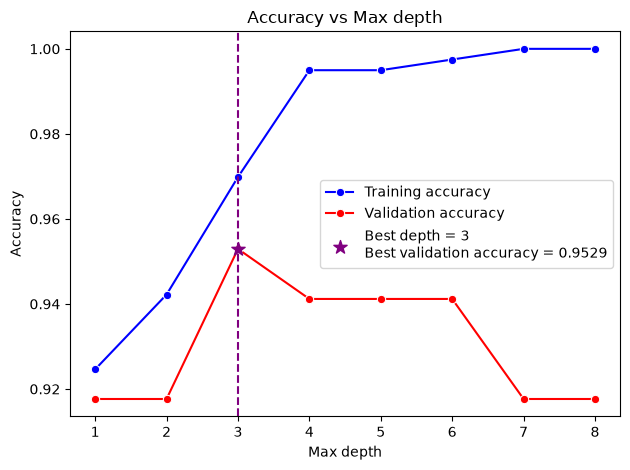

In [11]:
# plot curves for depth-wise metrics
sns.lineplot(data=depth_metrics, x="Max depth", y="Training accuracy", color="blue", marker='o', label="Training accuracy")
sns.lineplot(data=depth_metrics, x="Max depth", y="Validation accuracy", color="red", marker='o', label="Validation accuracy")

# mark the best max depth
best_id = depth_metrics["Validation accuracy"].idxmax()
best_max_depth = int(depth_metrics.loc[best_id, "Max depth"])
best_val_accuracy = depth_metrics.loc[best_id, "Validation accuracy"]
plt.axvline(best_max_depth, color="purple", linestyle="--")
plt.scatter(best_max_depth, best_val_accuracy,
    label=f"Best depth = {best_max_depth}\nBest validation accuracy = {best_val_accuracy:.4f}",
    zorder=10, marker='*', color="purple", s=100)

plt.title("Accuracy vs Max depth")
plt.xlabel("Max depth")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("plots/accuracy_vs_maxdepth.png")

In [12]:
# experiment with multiple min leaf samples
leaf_metrics = []

for leaf_size in range(1, 9):
    tree = DecisionTreeClassifier(min_samples_leaf=leaf_size)
    tree.fit(x_train, y_train)
    y_train_pred = tree.predict(x_train)
    y_val_pred = tree.predict(x_val)
    
    # calculate metrics for each leaf size
    leaf_metrics.append({
        "Min leaf samples": leaf_size,
        "Training accuracy" : accuracy_score(y_train, y_train_pred),
        "Validation accuracy": accuracy_score(y_val, y_val_pred)
    })
    
leaf_metrics = pd.DataFrame(leaf_metrics)
display(leaf_metrics)

,Min leaf samples,Training accuracy,Validation accuracy
0,1,1.000000,0.917647
1,2,0.989950,0.941176
2,3,0.987437,0.952941
3,4,0.982412,0.964706
4,5,0.979899,0.964706
5,6,0.977387,0.976471
6,7,0.959799,0.964706
7,8,0.944724,0.917647


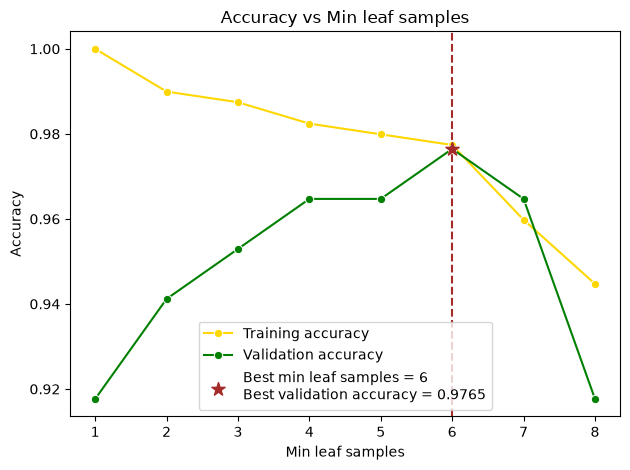

In [13]:
# plot curves for leaf-wise metrics
sns.lineplot(data=leaf_metrics, x="Min leaf samples", y="Training accuracy", color="gold", marker='o', label="Training accuracy")
sns.lineplot(data=leaf_metrics, x="Min leaf samples", y="Validation accuracy", color="green", marker='o', label="Validation accuracy")

# mark the best min leaf samples
best_id = leaf_metrics["Validation accuracy"].idxmax()
best_min_leaf_samples = int(leaf_metrics.loc[best_id, "Min leaf samples"])
best_val_accuracy = leaf_metrics.loc[best_id, "Validation accuracy"]
plt.axvline(best_min_leaf_samples, color="brown", linestyle="--")
plt.scatter(best_min_leaf_samples, best_val_accuracy,
    label=f"Best min leaf samples = {best_min_leaf_samples}\nBest validation accuracy = {best_val_accuracy:.4f}",
    zorder=10, marker='*', color="brown", s=100)

plt.title("Accuracy vs Min leaf samples")
plt.xlabel("Min leaf samples")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("plots/accuracy_vs_minleafsamples.png")

**Observations**

**1) Max Depth**
- Final setting: `max_depth = 3`, with the ***highest validation accuracy of 95.29%***.
- Underfitting: Appears at `depths 1–2`, where ***both training and validation accuracy are low***.
- Overfitting: Appears from `depth 4 onward`, as ***training accuracy approaches 100% while validation accuracy decreases***.
- Training accuracy: Alone is insufficient because deeper trees can achieve high training accuracy by memorizing the training data.

**2) Min Samples Leaf**
- Final setting: `min_leaf_samples = 6`, with the ***highest validation accuracy of 97.65%***.
- Underfitting: Appears at `leaf sizes > 6`, where ***both training and validation accuracy decrease***.
- Overfitting: Appears at `leaf size 1`, with ***100% training accuracy but very low validation accuracy***.
- Training accuracy: Alone should not be used because a smaller leaf size can improve training accuracy while reducing generalization.

## <font color='blue'>**Task 7: Categorical Split to Leaf Nodes**</font> **[Marks - 2]**

Use the following categorical dataset.

In [14]:
categorical_assignment_df = pd.DataFrame({
    "Weather": [
        "Sunny", "Sunny", "Cloudy", "Rainy",
        "Rainy", "Cloudy", "Sunny", "Rainy"
    ],
    "Wind": [
        "Weak", "Strong", "Weak", "Weak",
        "Strong", "Strong", "Weak", "Strong"
    ],
    "Traffic": [
        "High", "High", "Low", "Low",
        "High", "Low", "Low", "High"
    ],
    "Go_Out": [
        "No", "No", "Yes", "Yes",
        "No", "Yes", "Yes", "No"
    ]
})

categorical_assignment_df

,Weather,Wind,Traffic,Go_Out
0,Sunny,Weak,High,No
1,Sunny,Strong,High,No
2,Cloudy,Weak,Low,Yes
3,Rainy,Weak,Low,Yes
4,Rainy,Strong,High,No
5,Cloudy,Strong,Low,Yes
6,Sunny,Weak,Low,Yes
7,Rainy,Strong,High,No


Without using a Decision Tree library:

1. Calculate the parent Entropy.
2. Calculate Information Gain for every categorical feature.
3. Select the root feature.
4. Inspect each branch.
5. Split every impure branch again when possible.
6. Draw the final tree using Markdown/text.
7. Clearly identify all leaf predictions.

Show all intermediate calculations.

In [15]:
# Task 7
# Write your calculations/code here.

# Calculations & Tree diagram shown in the Markdown below this cell

## **Categorical Split to Leaf Nodes**

### **1. Parent Entropy**

There are 8 observations:

* `Yes = 4`
* `No = 4`

Entropy:

$$
H(S)=-\sum_{c}p_c\log_2(p_c)
$$

$$
=-\frac{4}{8}\log_2\left(\frac{4}{8}\right)
-\frac{4}{8}\log_2\left(\frac{4}{8}\right)
$$

$$
=-(0.5)(-1)-(0.5)(-1)
$$

$$
\boxed{H(S)=1.0000}
$$

---

### **2. Information Gain for `Weather`**

`Weather` has three categories: **Sunny, Cloudy, Rainy**.

#### **Sunny**

Rows: 1, 2, 7

* Yes = 1
* No = 2
* Total = 3

$$
H(Sunny)
=-\frac13\log_2\frac13
-\frac23\log_2\frac23
$$

$$
=-\frac13(-1.5850)-\frac23(-0.5850)
$$

$$
=0.5283+0.3900
$$

$$
\boxed{H(Sunny)=0.9183}
$$

#### **Cloudy**

Rows: 3, 6

* Yes = 2
* No = 0

$$
H(Cloudy)
=-1\log_2(1)-0\log_2(0)
$$

$$
\boxed{H(Cloudy)=0}
$$

The branch is pure because all observations are `Yes`.

#### **Rainy**

Rows: 4, 5, 8

* Yes = 1
* No = 2

Therefore,

$$
H(Rainy)
=-\frac13\log_2\frac13
-\frac23\log_2\frac23
$$

$$
\boxed{H(Rainy)=0.9183}
$$

#### **Weighted Entropy for Weather**

$$
H(S|Weather)
=
\frac38H(Sunny)
+\frac28H(Cloudy)
+\frac38H(Rainy)
$$

$$
=
\frac38(0.9183)
+\frac28(0)
+\frac38(0.9183)
$$

$$
=0.3444+0+0.3444
$$

$$
\boxed{H(S|Weather)=0.6887}
$$

#### **Information Gain**

$$
IG(Weather)=H(S)-H(S|Weather)
$$

$$
=1.0000-0.6887
$$

$$
\boxed{IG(Weather)=0.3113}
$$

---

### **3. Information Gain for `Wind`**

`Wind` has two categories: **Weak, Strong**.

#### **Weak**

Rows: 1, 3, 4, 7

* Yes = 3
* No = 1

$$
H(Weak)
=-\frac34\log_2\frac34
-\frac14\log_2\frac14
$$

$$
=-(0.75)(-0.4150)-(0.25)(-2)
$$

$$
=0.3113+0.5000
$$

$$
\boxed{H(Weak)=0.8113}
$$

#### **Strong**

Rows: 2, 5, 6, 8

* Yes = 1
* No = 3

$$
H(Strong)
=-\frac14\log_2\frac14
-\frac34\log_2\frac34
$$

$$
=-(0.25)(-2)-(0.75)(-0.4150)
$$

$$
=0.5000+0.3113
$$

$$
\boxed{H(Strong)=0.8113}
$$

#### **Weighted Entropy for Wind**

$$
H(S|Wind)
=
\frac48H(Weak)+\frac48H(Strong)
$$

$$
=\frac48(0.8113)+\frac48(0.8113)
$$

$$
=0.4057+0.4057
$$

$$
\boxed{H(S|Wind)=0.8113}
$$

#### **Information Gain**

$$
IG(Wind)
=1.0000-0.8113
$$

$$
\boxed{IG(Wind)=0.1887}
$$

---

### **4. Information Gain for `Traffic`**

`Traffic` has two categories: **High, Low**.

#### **High**

Rows: 1, 2, 5, 8

* Yes = 0
* No = 4

$$
H(High)
=-\frac44\log_2\frac44
-\frac04\log_2\frac04
$$

$$
=-1\log_2(1)-0
$$

$$
\boxed{H(High)=0}
$$

This is a pure `No` branch.

#### **Low**

Rows: 3, 4, 6, 7

* Yes = 4
* No = 0

$$
H(Low)
=-\frac44\log_2\frac44
-\frac04\log_2\frac04
$$

$$
=-1\log_2(1)-0
$$

$$
\boxed{H(Low)=0}
$$

This is a pure `Yes` branch.

#### **Weighted Entropy for Traffic**

$$
H(S|Traffic)
=
\frac48H(High)+\frac48H(Low)
$$

$$
=\frac48(0)+\frac48(0)
$$

$$
\boxed{H(S|Traffic)=0}
$$

#### **Information Gain**

$$
IG(Traffic)
=H(S)-H(S|Traffic)
$$

$$
=1.0000-0
$$

$$
\boxed{IG(Traffic)=1.0000}
$$

---

### **5. Compare Information Gain**

| Feature | Weighted Entropy | Information Gain |
| ------- | ---------------: | ---------------: |
| Weather |           0.6887 |       **0.3113** |
| Wind    |           0.8113 |       **0.1887** |
| Traffic |           0.0000 |       **1.0000** |

Since:

$$
IG(Traffic) > IG(Weather) > IG(Wind)
$$

the **root feature is `Traffic`**.

---

### **6. Inspect the Root Branches**

#### **Branch 1: Traffic = High**

Subset:

| Weather | Wind   | Traffic | Go_Out |
| ------- | ------ | ------- | ------ |
| Sunny   | Weak   | High    | No     |
| Sunny   | Strong | High    | No     |
| Rainy   | Strong | High    | No     |
| Rainy   | Strong | High    | No     |

Counts:

$$
Yes=0,\qquad No=4
$$

Entropy:

$$
H(High)=0
$$

Therefore, this branch is pure.

**Leaf prediction: `No`**

#### **Branch 2: Traffic = Low**

Subset:

| Weather | Wind   | Traffic | Go_Out |
| ------- | ------ | ------- | ------ |
| Cloudy  | Weak   | Low     | Yes    |
| Rainy   | Weak   | Low     | Yes    |
| Cloudy  | Strong | Low     | Yes    |
| Sunny   | Weak   | Low     | Yes    |

Counts:

$$
Yes=4,\qquad No=0
$$

Entropy:

$$
H(Low)=0
$$

Therefore, this branch is also pure.

**Leaf prediction: `Yes`**

Since **both branches are pure**, no further split is necessary.

---

### **7. Final Tree**

```text
                 Traffic
                /       \
             High        Low
              |           |
            `No`        `Yes`
           (Leaf)       (Leaf)
```

#### **Final Leaf Predictions**

* **Traffic = High → Go_Out = No**
* **Traffic = Low → Go_Out = Yes**

Thus, the final tree perfectly classifies all 8 training samples, with **training accuracy = 100%**.

In [16]:
# verification of the above calculations
# parent entropy
parent_entropy = entropy(categorical_assignment_df["Go_Out"])

# calculate all entropy and information gain values
results = []
for feature in categorical_assignment_df.columns[:-1]:
    weighted_entropy = 0
    branch_entropies = []
    for value, group in categorical_assignment_df.groupby(feature):
        branch_entropy = entropy(group["Go_Out"])
        branch_entropies.append(branch_entropy)
        weighted_entropy += len(group) / len(categorical_assignment_df) * branch_entropy
    
    information_gain = parent_entropy - weighted_entropy
    results.append({
        "Feature": feature,
        "Parent Entropy": parent_entropy,
        "Branch Entropies": ", ".join(f"{x:.4f}" for x in branch_entropies),
        "Weighted Entropy": weighted_entropy,
        "Information Gain": information_gain
    })

results_df = pd.DataFrame(results)

display(results_df.style.format({
    "Parent Entropy": "{:.4f}",
    "Weighted Entropy": "{:.4f}",
    "Information Gain": "{:.4f}"
}))

,Feature,Parent Entropy,Branch Entropies,Weighted Entropy,Information Gain
0,Weather,1.0000,"0.0000, 0.9183, 0.9183",0.6887,0.3113
1,Wind,1.0000,"0.8113, 0.8113",0.8113,0.1887
2,Traffic,1.0000,"0.0000, 0.0000",0.0000,1.0000


## <font color='blue'>**Task 8: Post-Pruning with Cost Complexity**</font> **[Mark - 2]**

Now Scikit-learn may be used.

Train an initially unrestricted `DecisionTreeClassifier`.

Obtain:

```python
cost_complexity_pruning_path()
```

Then train models across candidate `ccp_alpha` values.

Plot:

- training accuracy versus `ccp_alpha`;
- validation accuracy versus `ccp_alpha`.

Select an appropriate `ccp_alpha` using validation performance.

Report the selected tree's:

- depth;
- number of leaves;
- validation accuracy.

In [17]:
# Task 8
# Write your code here.
from sklearn.tree import DecisionTreeClassifier

sk_tree = DecisionTreeClassifier(random_state=42)
sk_tree.fit(x_train, y_train)

# obtain cost complexity pruning path
pruning_path = sk_tree.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = pruning_path.ccp_alphas    

# train models accross candidate ccp_alpha values
ccp_metrics = []

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    tree.fit(x_train, y_train)
    
    # calculate metrics for each ccp_alpha
    ccp_metrics.append({
        "ccp_alpha": alpha,
        "Training accuracy" : tree.score(x_train, y_train),
        "Validation accuracy": tree.score(x_val, y_val)
    })
    
ccp_metrics = pd.DataFrame(ccp_metrics)
display(ccp_metrics)

,ccp_alpha,Training accuracy,Validation accuracy
0,0.000000,1.000000,0.941176
1,0.002490,0.994975,0.964706
2,0.003350,0.992462,0.964706
3,0.004915,0.989950,0.976471
4,0.006353,0.987437,0.976471
5,0.008040,0.982412,0.976471
6,0.010720,0.969849,0.964706
7,0.014358,0.959799,0.929412
8,0.016235,0.944724,0.917647
9,0.017169,0.942211,0.917647


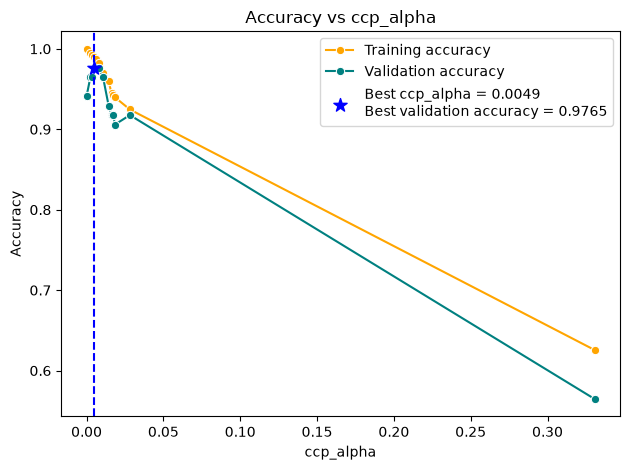

In [25]:
# plot curves for ccp-alpha metrics
sns.lineplot(data=ccp_metrics, x="ccp_alpha", y="Training accuracy", color="orange", marker='o', label="Training accuracy")
sns.lineplot(data=ccp_metrics, x="ccp_alpha", y="Validation accuracy", color="teal", marker='o', label="Validation accuracy")

# mark the best ccp_alpha value
best_id = ccp_metrics["Validation accuracy"].idxmax()
best_ccp_alpha = ccp_metrics.loc[best_id, "ccp_alpha"]
best_val_accuracy = ccp_metrics.loc[best_id, "Validation accuracy"]
plt.axvline(best_ccp_alpha, color="blue", linestyle="--")
plt.scatter(best_ccp_alpha, best_val_accuracy,
    label=f"Best ccp_alpha = {best_ccp_alpha:.4f}\nBest validation accuracy = {best_val_accuracy:.4f}",
    zorder=10, marker='*', color="blue", s=100)

plt.title("Accuracy vs ccp_alpha")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("plots/accuracy_vs_ccp_alpha.png")

In [26]:
# attributes of the tree with best ccp_alpha
best_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
best_tree.fit(x_train, y_train)

print(f"Selected ccp_alpha = {best_ccp_alpha:.4f}", )
print("Depth =", best_tree.get_depth())
print("Number of leaves =", best_tree.get_n_leaves())
print(f"Validation accuracy = {(best_tree.score(x_val, y_val) * 100):.2f}%")

Selected ccp_alpha = 0.0049
Depth = 4
Number of leaves = 10
Validation accuracy = 97.65%


## <font color='blue'>**Task 9: Regression Tree**</font> **[Marks - 2]**

Use `load_diabetes()`.

1. Create 70% / 15% / 15% train-validation-test partitions.
2. Train `DecisionTreeRegressor` for several values of `max_depth`.
3. Select the depth using validation RMSE.
4. Evaluate the selected model on the untouched test set.

Report:

- RMSE;
- MAE;
- $R^2$;
- fitted depth;
- number of leaves.

Also explain why the squared-error Regression Tree typically predicts the **mean target value** at a leaf.

In [31]:
# Task 9
# Write your code here
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

x = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='target')
print("Shape of features:", x.shape)
print("Shape of target:", y.shape)

# train-val-test split
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.30, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.50, random_state=42)

print("Shape of Training set:", x_train.shape)
print("Shape of Validation set:", x_val.shape)
print("Shape of Test set:", x_test.shape)

Shape of features: (442, 10)
Shape of target: (442,)
Shape of Training set: (309, 10)
Shape of Validation set: (66, 10)
Shape of Test set: (67, 10)


In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# train using multiple max depths
depth_metrics = []

for depth in range(1, 9):
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(x_train, y_train)
    
    y_train_pred = tree.predict(x_train)
    y_val_pred = tree.predict(x_val)
    
    # calculate Root Mean Squared Error (RMSE)
    depth_metrics.append({
        "Max depth": depth,
        "Training RMSE" : root_mean_squared_error(y_train, y_train_pred),
        "Validation RMSE": root_mean_squared_error(y_val, y_val_pred)
    })
    
depth_metrics = pd.DataFrame(depth_metrics)
display(depth_metrics)

,Max depth,Training RMSE,Validation RMSE
0,1,65.673392,62.262829
1,2,58.672457,54.364535
2,3,54.022909,56.413441
3,4,49.502589,57.389136
4,5,44.336431,59.778093
5,6,39.268790,62.767942
6,7,34.663543,68.651757
7,8,27.451797,73.055210


In [36]:
# best max depth based on validation RMSE
best_id = depth_metrics["Validation RMSE"].idxmin()
best_max_depth = int(depth_metrics.loc[best_id, "Max depth"])
best_val_rmse = depth_metrics.loc[best_id, "Validation RMSE"]

print(f"Best max. depth = {best_max_depth}")
print(f"Best validation RMSE = {best_val_rmse:.4f}")

Best max. depth = 2
Best validation RMSE = 54.3645


In [39]:
from sklearn.metrics import mean_absolute_error, r2_score

# make predictions on the untouched test set
best_tree = DecisionTreeRegressor(max_depth=best_max_depth, random_state=42)
best_tree.fit(x_train, y_train)
y_test_pred = best_tree.predict(x_test)

# calculate test metrics
test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Test RMSE =", test_rmse)
print("Test MAE =", test_mae)
print("Test R² =", test_r2)
print("Fitted depth =", best_tree.get_depth())
print("Number of leaves =", best_tree.get_n_leaves())

Test RMSE = 63.21362856680298
Test MAE = 51.44788018581221
Test R² = 0.2962349617777644
Fitted depth = 2
Number of leaves = 4


**Explanation**

A squared-error Regression Tree predicts the ***mean target value*** at a leaf because the mean minimizes the ***sum of squared errors (SSE)***:
$$
SSE=\sum_{i=1}^{n}(y_i-c)^2
$$

The value of \(c\) that minimizes this is:
$$
\boxed{c=\frac{1}{n}\sum_{i=1}^{n}y_i}
$$

Therefore, each leaf predicts the ***average of the target values of the training samples in that leaf***.

## **Marks Distribution**

| Task | Component | Marks |
|---:|---|---:|
| 1 | Dataset inspection | 1 |
| 2 | Train-validation-test split | 1 |
| 3 | Gini, Entropy and Information Gain | 3 |
| 4 | Scratch Decision Tree classifier | 5 |
| 5 | Gini vs Information Gain | 2 |
| 6 | Pre-pruning experiment | 2 |
| 7 | Categorical split to leaf nodes | 2 |
| 8 | Post-pruning | 2 |
| 9 | Regression Tree | 2 |
|  | **Total** | **20** |

---
End of the assignment